In [2]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

sns.set(style="whitegrid")

# Paths

BASE_DIR = Path().resolve().parent  
ML_DIR = BASE_DIR / "ML_pipeline"
print("BASE_DIR:", BASE_DIR)
print("ML_DIR:", ML_DIR)

# Match interp_type to how you trained the model
interp_type = "IDW"  # "kriging" or "IDW"

if interp_type == "IDW":
    interp_type_folder = "withIDW_v3"
elif interp_type == "kriging":
    interp_type_folder = "withKriging_v3"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
GRAPHICS_DIR = MODEL_OUT_DIR / "graphics_evaluation"
GRAPHICS_DIR.mkdir(exist_ok=True, parents=True)

print("MODEL_OUT_DIR:", MODEL_OUT_DIR)
print("GRAPHICS_DIR:", GRAPHICS_DIR)

BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v3
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v3\graphics_evaluation


In [3]:
# Consistent phase color scheme

PHASE_COLORS = {
    "Snow": "#1f77b4",   # blue
    "Rain": "#2ca02c",   # green
    "Mix":  "#e377c2"    # pink
}
PHASE_LABELS = {0: "Snow", 1: "Rain", 2: "Mix"}
PHASE_ORDER = ["Snow", "Rain", "Mix"]

sns.set_palette([PHASE_COLORS[p] for p in PHASE_ORDER])

In [4]:
# Load saved data

X_test_all = pd.read_parquet(MODEL_OUT_DIR / "X_test_all.parquet")
y_test_df = pd.read_parquet(MODEL_OUT_DIR / "y_test.parquet")
df_test_predictions = pd.read_parquet(MODEL_OUT_DIR / "test_predictions.parquet")

with open(MODEL_OUT_DIR / "model_metadata.json", "r") as f:
    metadata = json.load(f)

print("Loaded:")
print("  X_test_all:", X_test_all.shape)
print("  y_test_df:", y_test_df.shape)
print("  df_test_predictions:", df_test_predictions.shape)

threshold = metadata["confidence_threshold"]
print("Abstention threshold:", threshold)

Loaded:
  X_test_all: (3925329, 6)
  y_test_df: (3925329, 2)
  df_test_predictions: (3925329, 11)
Abstention threshold: 0.7849999999999999


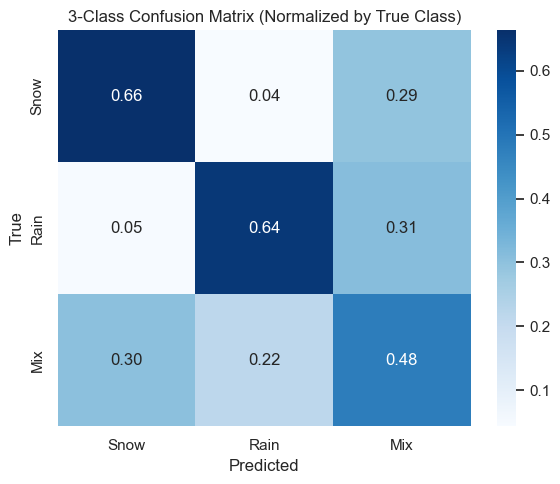

In [21]:
assert len(df_test_predictions) == len(X_test_all)
assert len(df_test_predictions) == len(y_test_df)

# ==========================================
# 3-CLASS CONFUSION MATRIX
# ==========================================

y_true = df_test_predictions["phase_full"].values
y_pred = df_test_predictions["pred_phase_abst"].values

labels = [0, 1, 2]
class_names = ["Snow", "Rain", "Mix"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("3-Class Confusion Matrix (Normalized by True Class)")
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "confusion_matrix_3class.png", dpi=300)
plt.show()

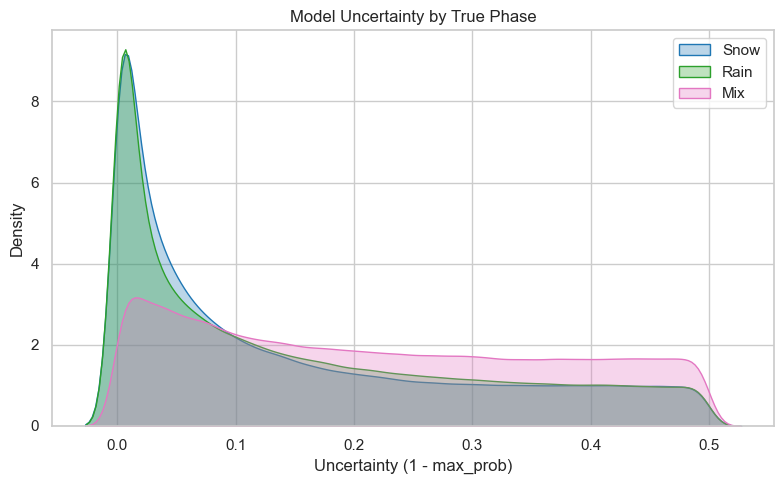

In [ ]:
# ==========================================
# UNCERTAINTY DISTRIBUTION BY TRUE CLASS (MAX PROB)
# ==========================================

df_test_predictions["uncertainty"] = 1 - df_test_predictions["max_prob"]

plt.figure(figsize=(8,5))

for cls, label in zip([0,1,2], PHASE_ORDER):
    subset = df_test_predictions[df_test_predictions["phase_full"] == cls]
    sns.kdeplot(
        subset["uncertainty"],
        label=label,
        fill=True,
        alpha=0.3,
        color=PHASE_COLORS[label]
    )

plt.xlabel("Uncertainty (1 - max_prob)")
plt.ylabel("Density")
plt.title("Model Uncertainty by True Phase")
plt.legend()
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "uncertainty_by_true_class.png", dpi=300)
plt.show()

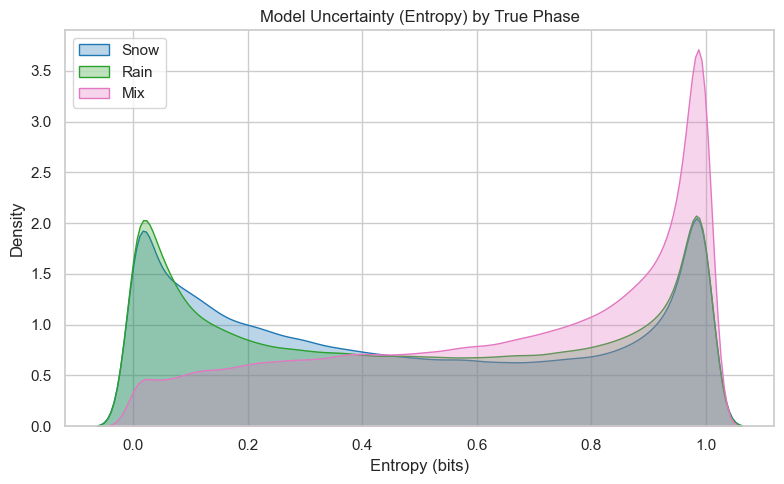

In [7]:
# ==========================================
# UNCERTAINTY DISTRIBUTION BY TRUE CLASS (ENTROPY)
# ==========================================

# Recompute entropy from probabilities
p_snow = df_test_predictions["p_snow"].to_numpy()
p_rain = df_test_predictions["p_rain"].to_numpy()

entropy = -(
    p_snow * np.log2(p_snow + 1e-12) +
    p_rain * np.log2(p_rain + 1e-12)
)

df_test_predictions["entropy"] = entropy

plt.figure(figsize=(8,5))

for cls, label in zip([0,1,2], PHASE_ORDER):
    subset = df_test_predictions[df_test_predictions["phase_full"] == cls]
    sns.kdeplot(
        subset["entropy"],
        label=label,
        fill=True,
        alpha=0.3,
        color=PHASE_COLORS[label]
    )

plt.xlabel("Entropy (bits)")
plt.ylabel("Density")
plt.title("Model Uncertainty (Entropy) by True Phase")
plt.legend()
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "entropy_by_true_class.png", dpi=300)
plt.show()

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_16160\358764012.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_16160\358764012.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(GRAPHICS_DIR / "probability_vs_wetbulb.png", dpi=300)
c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


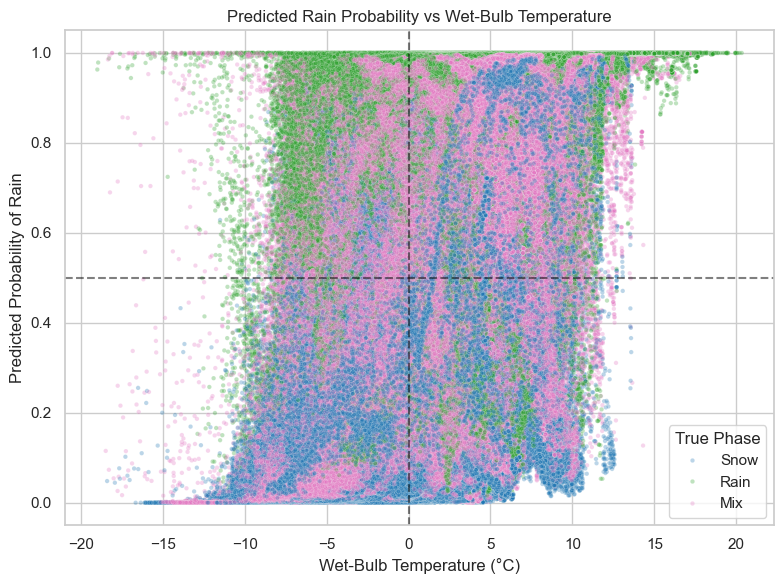

In [20]:
# ==========================================
# P_RAIN vs WET-BULB TEMPERATURE
# ==========================================

plt.figure(figsize=(8,6))

phase_labels = df_test_predictions["phase_full"].map(PHASE_LABELS)

sns.scatterplot(
    x=X_test_all["temp_wet"],
    y=df_test_predictions["p_rain"],
    hue=phase_labels,
    hue_order=PHASE_ORDER,
    palette=PHASE_COLORS,
    alpha=0.3,
    s=10
)

plt.axhline(0.5, linestyle="--", color="black", alpha=0.5)
plt.axvline(0.0, linestyle="--", color="black", alpha=0.5)

plt.xlabel("Wet-Bulb Temperature (°C)")
plt.ylabel("Predicted Probability of Rain")
plt.title("Predicted Rain Probability vs Wet-Bulb Temperature")
plt.legend(title="True Phase")
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "probability_vs_wetbulb.png", dpi=300)
plt.show()

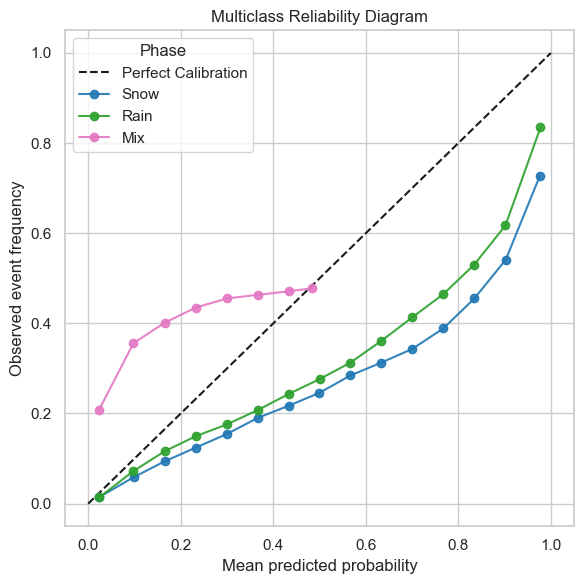

In [ ]:
def reliability_curve(probs, y_true, target_class, n_bins=15):
    """
    Compute reliability curve for a single class.

    probs: 1D array of predicted probabilities for the target class
    y_true: 1D array of integer class labels (0,1,2)
    target_class: int (0 for Snow, 1 for Rain, 2 for Mix)
    """
    y_binary = (y_true == target_class).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    obs_freq = []
    pred_mean = []
    counts = []

    for i in range(n_bins):
        idx = (probs >= bins[i]) & (probs < bins[i+1])
        if np.sum(idx) > 0:
            obs_freq.append(np.mean(y_binary[idx]))
            pred_mean.append(np.mean(probs[idx]))
            counts.append(np.sum(idx))
        else:
            obs_freq.append(np.nan)
            pred_mean.append(np.nan)
            counts.append(0)

    return np.array(pred_mean), np.array(obs_freq), np.array(counts), bin_centers


# p_snow and p_rain, define p_mix if needed
if "p_mix" not in df_test_predictions.columns:
    df_test_predictions["p_mix"] = 1.0 - df_test_predictions[["p_snow", "p_rain"]].max(axis=1)

p_snow = df_test_predictions["p_snow"].to_numpy()
p_rain = df_test_predictions["p_rain"].to_numpy()
p_mix  = df_test_predictions["p_mix"].to_numpy()

y_true = df_test_predictions["phase_full"].to_numpy()  # integer labels 0/1/2




plt.figure(figsize=(6,6))

# Perfect calibration line
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")

phase_probs = {
    0: p_snow,
    1: p_rain,
    2: p_mix,
}

for cls in [0, 1, 2]:
    label = PHASE_LABELS[cls]
    color = PHASE_COLORS[label]

    pred_mean, obs_freq, counts, bin_centers = reliability_curve(
        phase_probs[cls],
        y_true,
        target_class=cls,
        n_bins=15
    )

    # Filter NaNs so they don't break the lines
    mask_valid = ~np.isnan(pred_mean) & ~np.isnan(obs_freq)
    plt.plot(
        pred_mean[mask_valid],
        obs_freq[mask_valid],
        "o-",
        label=f"{label}",
        color=color,
        alpha=0.9,
    )

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event frequency")
plt.title("Reliability Diagram")
plt.legend(title="Phase")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_16160\77681492.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["tw_bin", "true"])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_16160\77681492.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["tw_bin", "pred"])


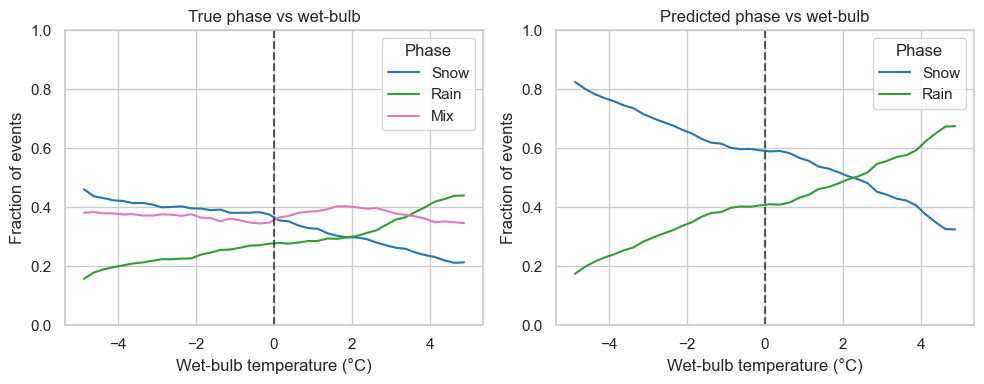

In [19]:
# =====================================================
# True vs predicted phase composition vs wet-bulb
# =====================================================

phase_col = "phase" if "phase" in df_test_predictions.columns else "phase_full"

# Pull arrays separately
temp_wet   = X_test_all["temp_wet"].to_numpy()
phase_true = df_test_predictions[phase_col].to_numpy()

# --- Get predicted phase as integers 0/1/2 ---
if "prediction" in df_test_predictions.columns:
    # Use existing column if present
    phase_pred = df_test_predictions["prediction"].to_numpy()
else:
    # Try to reconstruct from probability columns
    prob_cols_3 = ["p_snow", "p_rain", "p_mix"]
    prob_cols_2 = ["p_snow", "p_rain"]

    if all(c in df_test_predictions.columns for c in prob_cols_3):
        probs = df_test_predictions[prob_cols_3].to_numpy()
        phase_pred = probs.argmax(axis=1)   # 0 = Snow, 1 = Rain, 2 = Mix
    elif all(c in df_test_predictions.columns for c in prob_cols_2):
        probs_2 = df_test_predictions[prob_cols_2].to_numpy()
        p_mix = 1.0 - probs_2.max(axis=1)
        probs = np.column_stack([probs_2[:, 0], probs_2[:, 1], p_mix])
        phase_pred = probs.argmax(axis=1)
    else:
        raise ValueError(
            "Could not find 'prediction' or probability columns "
            "(['p_snow','p_rain','p_mix'] or ['p_snow','p_rain']) to derive predictions."
        )

# Restrict to near-freezing window
mask = (temp_wet >= -5.0) & (temp_wet <= 5.0)

tw_nf     = temp_wet[mask]
true_nf   = phase_true[mask]
pred_nf   = phase_pred[mask]

# Temporary DataFrame for binning/normalizing
comp_df = pd.DataFrame({
    "temp_wet": tw_nf,
    "true": true_nf,
    "pred": pred_nf,
})

bins = np.linspace(-5, 5, 41)
comp_df["tw_bin"] = pd.cut(comp_df["temp_wet"], bins=bins)

# --- True fractions ---
true_frac = (
    comp_df
    .groupby(["tw_bin", "true"])
    .size()
    .unstack(fill_value=0)
)
true_frac = true_frac.div(true_frac.sum(axis=1), axis=0)

# --- Predicted fractions ---
pred_frac = (
    comp_df
    .groupby(["tw_bin", "pred"])
    .size()
    .unstack(fill_value=0)
)
pred_frac = pred_frac.div(pred_frac.sum(axis=1), axis=0)

bin_centers = np.array([interval.mid for interval in true_frac.index])

plt.figure(figsize=(10,4))

# Panel 1: True
plt.subplot(1,2,1)
for cls in [0, 1, 2]:
    label = PHASE_LABELS[cls]
    if cls in true_frac.columns:
        plt.plot(
            bin_centers,
            true_frac[cls].values,
            label=label,
            color=PHASE_COLORS[label]
        )

plt.axvline(0.0, linestyle="--", alpha=0.7, color="k")
plt.ylim(0,1)
plt.xlabel("Wet-bulb temperature (°C)")
plt.ylabel("Fraction of events")
plt.title("True phase vs wet-bulb")
plt.legend(title="Phase", loc="best")

# Panel 2: Predicted
plt.subplot(1,2,2)
for cls in [0, 1, 2]:
    label = PHASE_LABELS[cls]
    if cls in pred_frac.columns:
        plt.plot(
            bin_centers,
            pred_frac[cls].values,
            label=label,
            color=PHASE_COLORS[label]
        )

plt.axvline(0.0, linestyle="--", alpha=0.7, color="k")
plt.ylim(0,1)
plt.xlabel("Wet-bulb temperature (°C)")
plt.ylabel("Fraction of events")
plt.title("Predicted phase vs wet-bulb")
plt.legend(title="Phase", loc="best")

plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "true_vs_pred_phase_vs_wetbulb.png", dpi=300)
plt.show()